# 4. Exploratory Data Analysis

## 4.2 Relationships and Patterns in the Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset produced by Task 3
cleaned_data_path = "../data/patient_data_cleaned.csv"
df_clean = pd.read_csv(cleaned_data_path)

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (278701, 40)


In [2]:
# Categorical variables to compare with the heart disease target
categorical_variables = [
    "gender",
    "age_level",
    "bmi_level",
    "smoking",
    "physical_activity",
    "family_history",
    "diabetes",
    "stress_level"
]

# Calculate the percentage of heart disease cases in each category
for column in categorical_variables:
    heart_disease_rate = (
        df_clean
        .groupby(column)["heart_disease_target"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .round(2)
    )

    print(f"\nHeart disease rate by {column}:")
    print(heart_disease_rate)


Heart disease rate by gender:
gender
Male      2.53
Female    1.74
Name: heart_disease_target, dtype: float64

Heart disease rate by age_level:
age_level
Senior    3.71
Mature    2.57
Middle    1.04
Young     0.50
Name: heart_disease_target, dtype: float64

Heart disease rate by bmi_level:
bmi_level
Overweight     3.04
Obese          2.32
Normal         1.66
Underweight    0.29
Name: heart_disease_target, dtype: float64

Heart disease rate by smoking:
smoking
Former     2.34
Never      2.05
Current    1.97
Name: heart_disease_target, dtype: float64

Heart disease rate by physical_activity:
physical_activity
High        2.38
Low         1.97
Moderate    1.87
Name: heart_disease_target, dtype: float64

Heart disease rate by family_history:
family_history
No     2.26
Yes    1.93
Name: heart_disease_target, dtype: float64

Heart disease rate by diabetes:
diabetes
Yes    2.23
No     2.05
Name: heart_disease_target, dtype: float64

Heart disease rate by stress_level:
stress_level
High      

In [3]:
# Check whether heart disease rates differ between the source datasets
source_rate = (
    df_clean
    .groupby("source_dataset")["heart_disease_target"]
    .mean()
    .mul(100)
    .round(2)
)

print("Heart disease rate by source dataset:")
print(source_rate)

Heart disease rate by source dataset:
source_dataset
diabetes         4.17
heart           20.06
hypertension     0.00
Name: heart_disease_target, dtype: float64


In [4]:
# Compare source dataset with the heart disease target
source_target_counts = pd.crosstab(
    df_clean["source_dataset"],
    df_clean["heart_disease_target"]
)

print(source_target_counts)

# Also check the disease sublabels within each source dataset
source_sublabel_counts = pd.crosstab(
    df_clean["source_dataset"],
    df_clean["sublabel"]
)

print("\nSublabel distribution by source dataset:")
print(source_sublabel_counts)

heart_disease_target   False  True 
source_dataset                     
diabetes               89934   3910
heart                   7894   1981
hypertension          174982      0

Sublabel distribution by source dataset:
sublabel           DI  DI_HT  DI_HT_HY  DI_HY    HT  HT_HY     HY      N
source_dataset                                                          
diabetes         5472    909       358   1727  2087    556   4799  77936
heart            1967    489       487   1965   496    509   1987   1975
hypertension    24464      0         0  62780     0      0  63001  24737


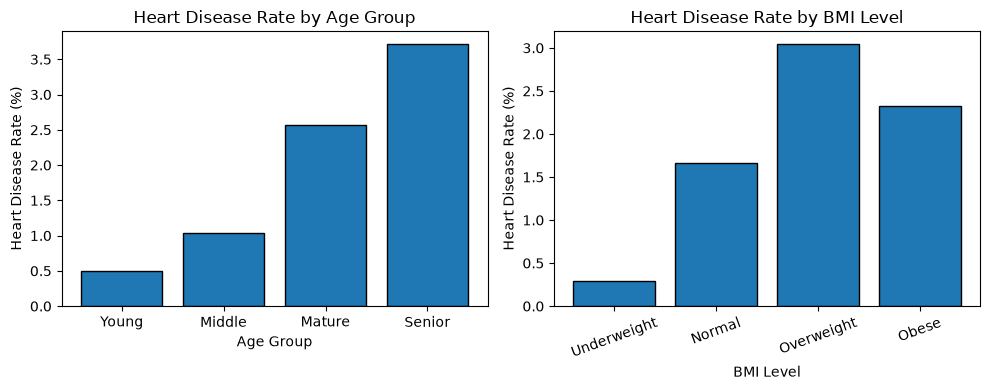

In [5]:
# Compare heart disease rate across age and BMI groups
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Heart disease rate by age level
age_rate = (
    df_clean
    .groupby("age_level")["heart_disease_target"]
    .mean()
    .mul(100)
)

# Put the age groups in a meaningful order
age_order = ["Young", "Middle", "Mature", "Senior"]
age_rate = age_rate.reindex(age_order)

axes[0].bar(
    age_rate.index,
    age_rate.values,
    edgecolor="black"
)

axes[0].set_title("Heart Disease Rate by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Heart Disease Rate (%)")


# Heart disease rate by BMI level
bmi_rate = (
    df_clean
    .groupby("bmi_level")["heart_disease_target"]
    .mean()
    .mul(100)
)

bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
bmi_rate = bmi_rate.reindex(bmi_order)

axes[1].bar(
    bmi_rate.index,
    bmi_rate.values,
    edgecolor="black"
)

axes[1].set_title("Heart Disease Rate by BMI Level")
axes[1].set_xlabel("BMI Level")
axes[1].set_ylabel("Heart Disease Rate (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

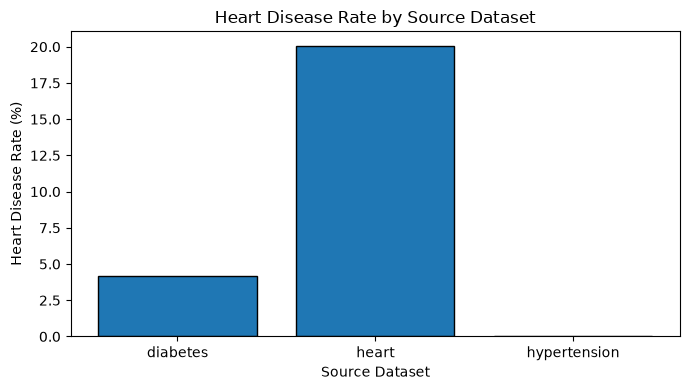

In [6]:
# Calculate heart disease rate for each source dataset
source_rate = (
    df_clean
    .groupby("source_dataset")["heart_disease_target"]
    .mean()
    .mul(100)
)

# Plot the heart disease rate by source dataset
plt.figure(figsize=(7, 4))

plt.bar(
    source_rate.index,
    source_rate.values,
    edgecolor="black"
)

plt.xlabel("Source Dataset")
plt.ylabel("Heart Disease Rate (%)")
plt.title("Heart Disease Rate by Source Dataset")

plt.tight_layout()
plt.show()

Heart disease rates differ substantially by source dataset: 20.06% for the heart source, 4.17% for diabetes and 0% for hypertension. This shows that source composition is important when interpreting combined results.

                age   bmi  glucose  cholesterol  triglycerides  systolic_bp  \
age            1.00  0.10     0.03         0.03          -0.16          0.0   
bmi            0.10  1.00     0.03         0.03          -0.01         -0.0   
glucose        0.03  0.03     1.00         0.00          -0.00          0.0   
cholesterol    0.03  0.03     0.00         1.00          -0.03         -0.0   
triglycerides -0.16 -0.01    -0.00        -0.03           1.00         -0.0   
systolic_bp    0.00 -0.00     0.00        -0.00          -0.00          1.0   
diastolic_bp   0.00  0.00     0.00         0.00           0.01          0.0   
heart_rate    -0.00 -0.00    -0.00        -0.00           0.00         -0.0   
hdl           -0.00 -0.00     0.00        -0.00           0.00          0.0   
ldl           -0.01 -0.00    -0.00        -0.00           0.00         -0.0   

               diastolic_bp  heart_rate  hdl   ldl  
age                    0.00        -0.0 -0.0 -0.01  
bmi                    0

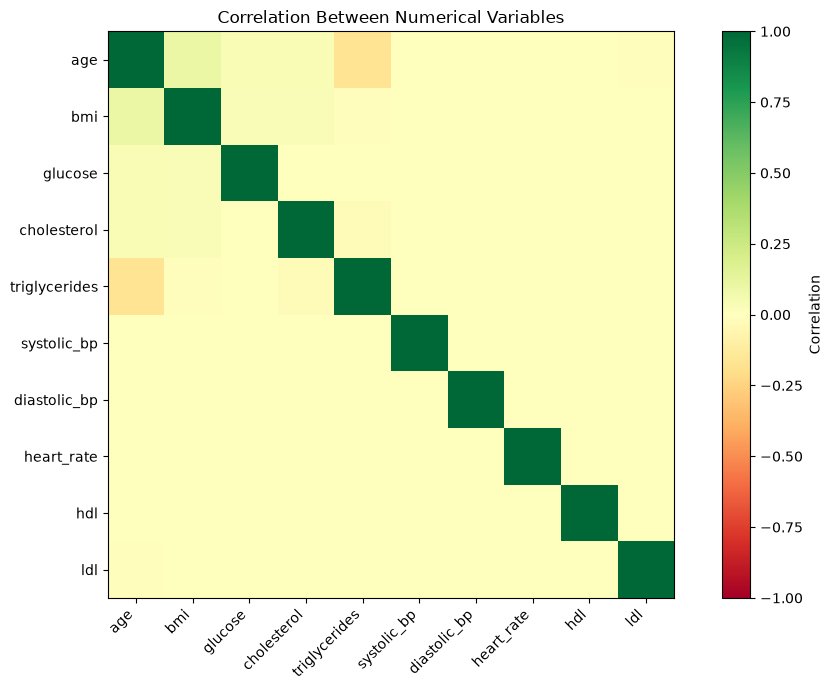

In [7]:
# Select numerical variables for correlation analysis
correlation_columns = [
    "age",
    "bmi",
    "glucose",
    "cholesterol",
    "triglycerides",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hdl",
    "ldl"
]

# Calculate the correlation matrix
correlation_matrix = df_clean[correlation_columns].corr()

print(correlation_matrix.round(2))

# Plot the correlation heatmap
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

Most correlations between the selected numerical variables are weak. The largest displayed relationship is a small negative correlation between age and triglycerides (-0.16).

In [8]:
# Numerical variables to compare between the two target classes
target_numeric_columns = [
    "age",
    "bmi",
    "glucose",
    "cholesterol",
    "triglycerides",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hdl",
    "ldl"
]

# Calculate the mean of each variable for both target classes
target_means = (
    df_clean
    .groupby("heart_disease_target")[target_numeric_columns]
    .mean()
    .T
)

# Give the target classes clearer names
target_means.columns = [
    "No Heart Disease",
    "Heart Disease"
]

# Calculate the difference between the two groups
target_means["Difference"] = (
    target_means["Heart Disease"]
    - target_means["No Heart Disease"]
)

print(target_means.round(2))

               No Heart Disease  Heart Disease  Difference
age                       49.46          61.44       11.98
bmi                       27.45          29.33        1.88
glucose                  135.13         141.45        6.32
cholesterol              224.00         225.11        1.10
triglycerides            177.67         219.05       41.39
systolic_bp              134.41         134.53        0.13
diastolic_bp              89.48          89.51        0.03
heart_rate                74.50          74.42       -0.08
hdl                       64.61          64.54       -0.07
ldl                      129.72         129.48       -0.25


Heart disease records are older on average and have higher mean BMI, glucose and triglycerides. The largest mean differences are 41.39 for triglycerides and 11.98 years for age.

In [9]:
# Compare the main numerical differences within each source dataset
source_target_means = (
    df_clean
    .groupby(["source_dataset", "heart_disease_target"])[
        ["age", "bmi", "glucose", "triglycerides"]
    ]
    .mean()
    .round(2)
)

print(source_target_means)

                                       age    bmi  glucose  triglycerides
source_dataset heart_disease_target                                      
diabetes       False                 41.61  27.23   137.71         225.93
               True                  67.73  29.34   152.35         202.80
heart          False                 49.38  29.01   120.14         250.64
               True                  49.03  29.30   119.94         251.13
hypertension   False                 53.49  27.49   134.49         149.57


In [10]:
# Compare heart disease rates by age group within each source dataset
age_source_rate = (
    df_clean
    .groupby(["source_dataset", "age_level"])["heart_disease_target"]
    .mean()
    .mul(100)
    .round(2)
)

print("Heart disease rate by age group and source:")
print(age_source_rate)


# Compare heart disease rates by BMI group within each source dataset
bmi_source_rate = (
    df_clean
    .groupby(["source_dataset", "bmi_level"])["heart_disease_target"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nHeart disease rate by BMI group and source:")
print(bmi_source_rate)

Heart disease rate by age group and source:
source_dataset  age_level
diabetes        Mature        5.28
                Middle        0.53
                Senior       15.11
                Young         0.04
heart           Mature       19.28
                Middle       21.09
                Senior       19.88
                Young        19.50
hypertension    Mature        0.00
                Middle        0.00
                Senior        0.00
                Young         0.00
Name: heart_disease_target, dtype: float64

Heart disease rate by BMI group and source:
source_dataset  bmi_level  
diabetes        Normal          2.94
                Obese           5.70
                Overweight      4.72
                Underweight     0.54
heart           Normal         18.60
                Obese          20.86
                Overweight     20.11
                Underweight    21.59
hypertension    Normal          0.00
                Obese           0.00
                Overweig

In [11]:
# Compare heart disease rates for combinations of age and BMI groups
age_bmi_pattern = (
    df_clean
    .groupby(["age_level", "bmi_level"])
    ["heart_disease_target"]
    .agg(["mean", "count"])
)

# Convert the mean into a percentage
age_bmi_pattern["heart_disease_rate"] = (
    age_bmi_pattern["mean"] * 100
)

# Keep the useful columns
age_bmi_pattern = age_bmi_pattern[
    ["heart_disease_rate", "count"]
]

print(age_bmi_pattern.round(2))

                       heart_disease_rate  count
age_level bmi_level                             
Mature    Normal                     1.74  20074
          Obese                      3.00  33274
          Overweight                 3.37  25587
          Underweight                0.33   8084
Middle    Normal                     0.98  21471
          Obese                      1.36  31305
          Overweight                 0.95  23711
          Underweight                0.16   7991
Senior    Normal                     3.20  17666
          Obese                      3.00  25700
          Overweight                 6.53  18425
          Underweight                0.63   8033
Young     Normal                     0.42  11380
          Obese                      1.11   8098
          Overweight                 0.49   9174
          Underweight                0.05   8728


In [12]:
# Examine the same Age + BMI pattern separately for each source dataset
for source in ["diabetes", "heart"]:

    source_data = df_clean[
        df_clean["source_dataset"] == source
    ]

    pattern = (
        source_data
        .groupby(["age_level", "bmi_level"])
        ["heart_disease_target"]
        .agg(["mean", "count"])
    )

    pattern["heart_disease_rate"] = pattern["mean"] * 100

    print(f"\n{source.upper()} SOURCE")
    print(
        pattern[
            ["heart_disease_rate", "count"]
        ].round(2)
    )


DIABETES SOURCE
                       heart_disease_rate  count
age_level bmi_level                             
Mature    Normal                     3.41   5109
          Obese                      6.73  10294
          Overweight                 5.08  13955
          Underweight                1.17    598
Middle    Normal                     0.35   6635
          Obese                      0.84   8008
          Overweight                 0.44  12370
          Underweight                0.28    719
Senior    Normal                    14.21   3201
          Obese                     16.77   3447
          Overweight                15.31   7209
          Underweight                6.78    516
Young     Normal                     0.01   7255
          Obese                      0.17   1775
          Overweight                 0.05   6101
          Underweight                0.03   6652

HEART SOURCE
                       heart_disease_rate  count
age_level bmi_level                   

In [13]:
# Explore a combination of three patient characteristics
combined_pattern = (
    df_clean
    .groupby(
        ["age_level", "bmi_level", "gender"]
    )
    ["heart_disease_target"]
    .agg(["mean", "count"])
)

combined_pattern["heart_disease_rate"] = (
    combined_pattern["mean"] * 100
)

combined_pattern = (
    combined_pattern[
        ["heart_disease_rate", "count"]
    ]
    .sort_values(
        "heart_disease_rate",
        ascending=False
    )
)

print(combined_pattern.round(2))

                              heart_disease_rate  count
age_level bmi_level   gender                           
Senior    Overweight  Male                  8.18   8941
                      Female                4.99   9484
Mature    Overweight  Male                  4.63  12290
          Obese       Male                  3.72  15796
Senior    Obese       Male                  3.41  12488
          Normal      Male                  3.27   8432
                      Female                3.14   9234
          Obese       Female                2.60  13212
Mature    Obese       Female                2.35  17478
          Overweight  Female                2.21  13297
          Normal      Male                  2.07   8936
                      Female                1.47  11138
Middle    Obese       Male                  1.45  14543
                      Female                1.28  16762
Young     Obese       Female                1.12   4270
                      Male                  1.10

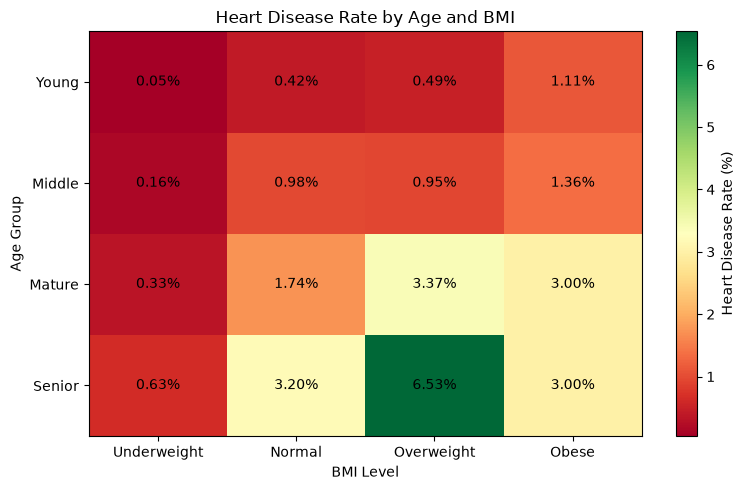

In [14]:
# Create a table of heart disease rates for each Age + BMI combination
age_bmi_heatmap = (
    df_clean
    .groupby(["age_level", "bmi_level"])["heart_disease_target"]
    .mean()
    .mul(100)
    .unstack()
)

# Put categories in a meaningful order
age_order = ["Young", "Middle", "Mature", "Senior"]
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]

age_bmi_heatmap = age_bmi_heatmap.loc[
    age_order,
    bmi_order
]

# Plot the heatmap
plt.figure(figsize=(8, 5))

plt.imshow(
    age_bmi_heatmap.values,
    cmap="RdYlGn",
    aspect="auto"
)

plt.colorbar(label="Heart Disease Rate (%)")

plt.xticks(
    range(len(bmi_order)),
    bmi_order
)

plt.yticks(
    range(len(age_order)),
    age_order
)

# Add the percentage inside each cell
for i in range(len(age_order)):
    for j in range(len(bmi_order)):
        plt.text(
            j,
            i,
            f"{age_bmi_heatmap.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )

plt.xlabel("BMI Level")
plt.ylabel("Age Group")
plt.title("Heart Disease Rate by Age and BMI")

plt.tight_layout()
plt.show()

The highest combined rate is 6.53% for senior overweight records, while young underweight records have the lowest rate at 0.05%. Rates generally differ across both age and BMI groups.

In [15]:
# Lifestyle and demographic features to compare with heart disease
lifestyle_features = [
    "gender",
    "smoking",
    "physical_activity",
    "family_history",
    "stress_level"
]

for column in lifestyle_features:

    # Overall heart disease rate for each category
    overall_rate = (
        df_clean
        .groupby(column)["heart_disease_target"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(f"\n--- {column.upper()} ---")
    print("Overall:")
    print(overall_rate)

    # Check whether the same pattern appears within each source dataset
    source_rate = (
        df_clean
        .groupby(["source_dataset", column])["heart_disease_target"]
        .mean()
        .mul(100)
        .round(2)
    )

    print("\nBy source dataset:")
    print(source_rate)


--- GENDER ---
Overall:
gender
Female    1.74
Male      2.53
Name: heart_disease_target, dtype: float64

By source dataset:
source_dataset  gender
diabetes        Female     2.83
                Male       6.03
heart           Female    20.66
                Male      19.46
hypertension    Female     0.00
                Male       0.00
Name: heart_disease_target, dtype: float64

--- SMOKING ---
Overall:
smoking
Current    1.97
Former     2.34
Never      2.05
Name: heart_disease_target, dtype: float64

By source dataset:
source_dataset  smoking
diabetes        Current     4.44
                Former      8.70
                Never       2.58
heart           Current    20.21
                Never      19.90
hypertension    Current     0.00
                Former      0.00
                Never       0.00
Name: heart_disease_target, dtype: float64

--- PHYSICAL_ACTIVITY ---
Overall:
physical_activity
High        2.38
Low         1.97
Moderate    1.87
Name: heart_disease_target, dtype: f


By source dataset:
source_dataset  family_history
diabetes        No                 3.97
                Yes                4.59
heart           No                20.31
                Yes               19.81
hypertension    No                 0.00
                Yes                0.00
Name: heart_disease_target, dtype: float64

--- STRESS_LEVEL ---
Overall:
stress_level
High      2.19
Low       1.96
Medium    2.18
Name: heart_disease_target, dtype: float64

By source dataset:
source_dataset  stress_level
diabetes        High             4.02
                Low              4.10
                Medium           4.45
heart           High            19.92
                Low             18.67
                Medium          21.57
hypertension    High             0.00
                Low              0.00
                Medium           0.00
Name: heart_disease_target, dtype: float64


In [16]:
# Numerical lifestyle and clinical variables
numeric_features = [
    "sleep_hours",
    "alcohol_intake",
    "salt_intake",
    "glucose",
    "HbA1c_level",
    "cholesterol",
    "triglycerides",
    "crp_level",
    "homocysteine_level",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hdl",
    "ldl"
]

# Compare the mean values between the two target classes
overall_means = (
    df_clean
    .groupby("heart_disease_target")[numeric_features]
    .mean()
    .T
)

overall_means.columns = [
    "No Heart Disease",
    "Heart Disease"
]

overall_means["Difference"] = (
    overall_means["Heart Disease"]
    - overall_means["No Heart Disease"]
)

print("OVERALL")
print(overall_means.round(2))


# Repeat the comparison inside each useful source dataset
for source in ["diabetes", "heart"]:

    source_data = df_clean[
        df_clean["source_dataset"] == source
    ]

    source_means = (
        source_data
        .groupby("heart_disease_target")[numeric_features]
        .mean()
        .T
    )

    source_means.columns = [
        "No Heart Disease",
        "Heart Disease"
    ]

    source_means["Difference"] = (
        source_means["Heart Disease"]
        - source_means["No Heart Disease"]
    )

    print(f"\n{source.upper()} SOURCE")
    print(source_means.round(2))

OVERALL
                    No Heart Disease  Heart Disease  Difference
sleep_hours                     6.95           6.99        0.04
alcohol_intake                 15.00          14.99       -0.02
salt_intake                     8.48           8.49        0.01
glucose                       135.13         141.45        6.32
HbA1c_level                     5.95           5.98        0.03
cholesterol                   224.00         225.11        1.10
triglycerides                 177.67         219.05       41.39
crp_level                       7.49           7.50        0.02
homocysteine_level             12.46          12.50        0.04
systolic_bp                   134.41         134.53        0.13
diastolic_bp                   89.48          89.51        0.03
heart_rate                     74.50          74.42       -0.08
hdl                            64.61          64.54       -0.07
ldl                           129.72         129.48       -0.25

DIABETES SOURCE
               

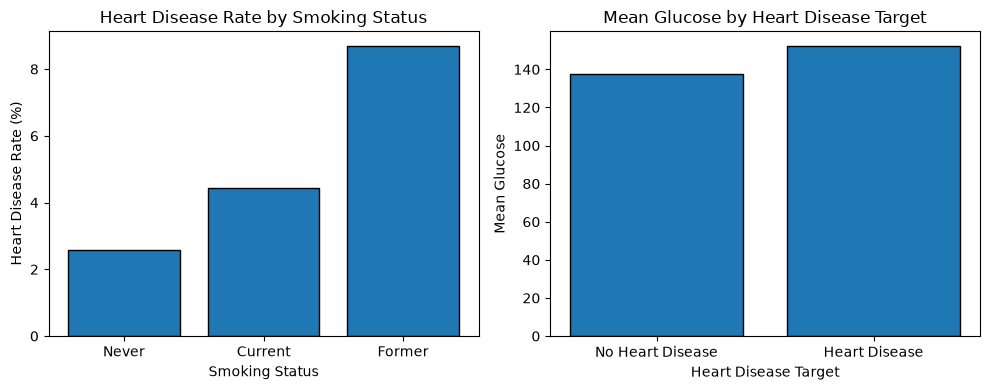

In [17]:
# Use only the diabetes source because this is where
# smoking and glucose showed clearer target differences
diabetes_data = df_clean[
    df_clean["source_dataset"] == "diabetes"
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --------------------
# Smoking
# --------------------

smoking_rate = (
    diabetes_data
    .groupby("smoking")["heart_disease_target"]
    .mean()
    .mul(100)
)

smoking_order = ["Never", "Current", "Former"]
smoking_rate = smoking_rate.reindex(smoking_order)

axes[0].bar(
    smoking_rate.index,
    smoking_rate.values,
    edgecolor="black"
)

axes[0].set_xlabel("Smoking Status")
axes[0].set_ylabel("Heart Disease Rate (%)")
axes[0].set_title("Heart Disease Rate by Smoking Status")


# --------------------
# Glucose
# --------------------

glucose_means = (
    diabetes_data
    .groupby("heart_disease_target")["glucose"]
    .mean()
)

axes[1].bar(
    ["No Heart Disease", "Heart Disease"],
    [
        glucose_means[False],
        glucose_means[True]
    ],
    edgecolor="black"
)

axes[1].set_xlabel("Heart Disease Target")
axes[1].set_ylabel("Mean Glucose")
axes[1].set_title("Mean Glucose by Heart Disease Target")

plt.tight_layout()
plt.show()

Within the diabetes source, former smokers have the highest heart disease rate at 8.70%. Mean glucose is also higher for heart disease records (152.35) than for records without heart disease (137.71).

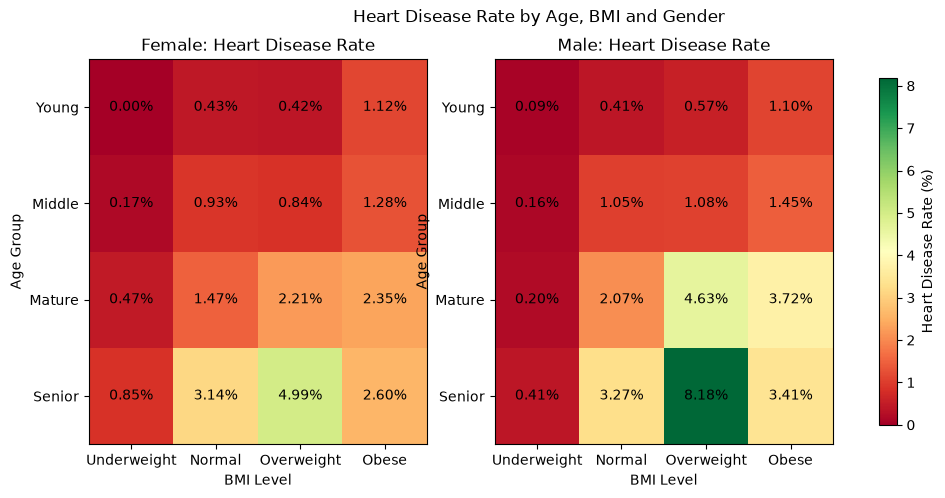

In [18]:
# Compare Age + BMI patterns separately for females and males

age_order = ["Young", "Middle", "Mature", "Senior"]
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]

gender_heatmaps = {}

# Calculate the heart disease rate for each combination
for gender in ["Female", "Male"]:

    gender_data = df_clean[
        df_clean["gender"] == gender
    ]

    rates = (
        gender_data
        .groupby(["age_level", "bmi_level"])["heart_disease_target"]
        .mean()
        .mul(100)
        .unstack()
    )

    rates = rates.reindex(
        index=age_order,
        columns=bmi_order
    )

    gender_heatmaps[gender] = rates


# Use the same scale for both heatmaps
max_rate = max(
    gender_heatmaps["Female"].max().max(),
    gender_heatmaps["Male"].max().max()
)


# Create one heatmap for each gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, gender in zip(axes, ["Female", "Male"]):

    rates = gender_heatmaps[gender]

    image = ax.imshow(
        rates.values,
        cmap="RdYlGn",
        vmin=0,
        vmax=max_rate,
        aspect="auto"
    )

    ax.set_xticks(range(len(bmi_order)))
    ax.set_xticklabels(bmi_order)

    ax.set_yticks(range(len(age_order)))
    ax.set_yticklabels(age_order)

    ax.set_xlabel("BMI Level")
    ax.set_ylabel("Age Group")
    ax.set_title(f"{gender}: Heart Disease Rate")

    # Display the percentage inside each cell
    for i in range(len(age_order)):
        for j in range(len(bmi_order)):
            ax.text(
                j,
                i,
                f"{rates.iloc[i, j]:.2f}%",
                ha="center",
                va="center"
            )


fig.colorbar(
    image,
    ax=axes,
    label="Heart Disease Rate (%)",
    shrink=0.9
)

plt.suptitle(
    "Heart Disease Rate by Age, BMI and Gender"
)

plt.show()

The senior overweight group has the highest displayed rate for both genders, with 8.18% for males and 4.99% for females.

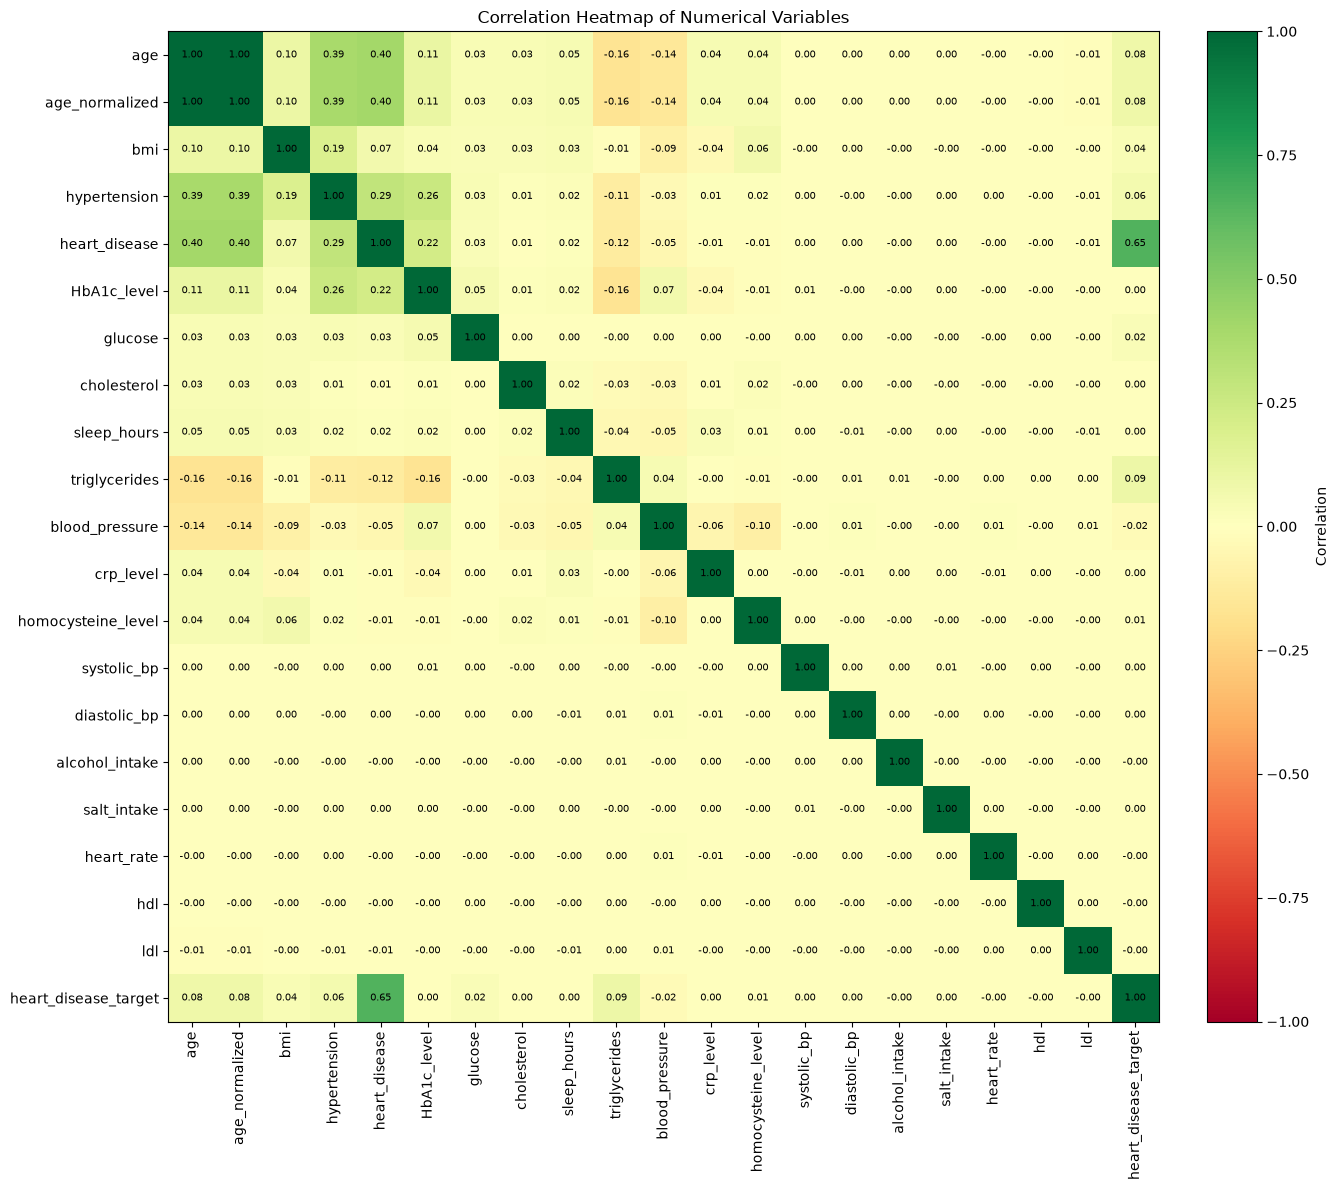

In [19]:


# Select numerical columns for correlation analysis
# This includes integers, floats, and the boolean target
correlation_data = df_clean.select_dtypes(
    include=["int64", "float64", "bool"]
).copy()

# Convert the boolean target into integers for correlation
correlation_data["heart_disease_target"] = (
    correlation_data["heart_disease_target"].astype(int)
)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create a larger figure for readability
plt.figure(figsize=(14, 12))

# Plot the correlation heatmap
image = plt.imshow(
    correlation_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

# Add the colour bar
plt.colorbar(image, label="Correlation", fraction=0.046, pad=0.04)

# Add axis labels
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

# Add correlation values inside the cells
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

# Add title
plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

Age and `age_normalized` are perfectly correlated because they represent the same measure on different scales. The target has its strongest displayed relationship with the original `heart_disease` field, while most other numerical relationships are weaker.